# Phase 6: Advanced Modeling — Improving Your Kaggle Score

Key improvements over Phase 5 baseline:
- **Log-transform target** (Kaggle scores on RMSLE)
- **Regularization** (Ridge, Lasso, ElasticNet) — prevents overfitting with 200+ features
- **Tree-based models** (Random Forest, XGBoost, LightGBM) — capture non-linear patterns
- **5-Fold Cross-Validation** — reliable performance estimate
- **Weighted Ensemble** — blends models to cancel out individual errors


## Task 1: Import Required Libraries

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
import warnings
warnings.filterwarnings('ignore')

# sklearn tools
from sklearn.model_selection  import train_test_split, cross_val_score, KFold
from sklearn.metrics          import mean_squared_error, r2_score, mean_absolute_error
from sklearn.preprocessing    import StandardScaler, RobustScaler
from sklearn.pipeline         import Pipeline

# Linear models
from sklearn.linear_model import Ridge, Lasso, ElasticNet, LinearRegression

# Tree-based models
from sklearn.ensemble import RandomForestRegressor
import xgboost  as xgb
import lightgbm as lgb

sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (12, 6)
SEED = 42
print('All libraries loaded successfully.')


All libraries loaded successfully.


## Task 2: Load Data and Log-Transform the Target

**Why log-transform SalePrice?**  
Kaggle evaluates this competition using RMSLE. Predicting `log1p(SalePrice)` and converting
back with `expm1` is the correct approach — it converts RMSLE into plain RMSE and
normalises the right-skewed target distribution.


In [2]:
# ── Load raw data ──────────────────────────────────────────────────────
import os

# Try Solutions/ path first (spec), fall back to data/ directories
TRAIN_PATHS = [
    'Solutions/train_feature_engineered.csv',
    '../data/processed/train_cleaned.csv',
    'train_cleaned.csv',
]
TEST_PATHS = [
    'Solutions/test_feature_engineered.csv',
    '../data/raw/test.csv',
    'test.csv',
]

def find_file(paths):
    for p in paths:
        if os.path.exists(p):
            return p
    raise FileNotFoundError(f'None of these paths exist: {paths}')

train = pd.read_csv(find_file(TRAIN_PATHS))
test  = pd.read_csv(find_file(TEST_PATHS))

# Save IDs before any transforms
train_ids = train['Id'].copy()
test_ids  = test['Id'].copy()

print(f'Train shape : {train.shape}')
print(f'Test shape  : {test.shape}')
print(f'SalePrice range: ${train.SalePrice.min():,} – ${train.SalePrice.max():,}')


Train shape : (1458, 77)
Test shape  : (1459, 80)
SalePrice range: $34,900 – $755,000


=== Raw SalePrice ===
count      1458.00
mean     180932.92
std       79495.06
min       34900.00
25%      129925.00
50%      163000.00
75%      214000.00
max      755000.00
Name: SalePrice, dtype: float64
Skewness: 1.8794

=== Log-Transformed SalePrice ===
count    1458.0000
mean       12.0240
std         0.3997
min        10.4603
25%        11.7747
50%        12.0015
75%        12.2737
max        13.5345
Name: SalePrice, dtype: float64
Skewness: 0.1215


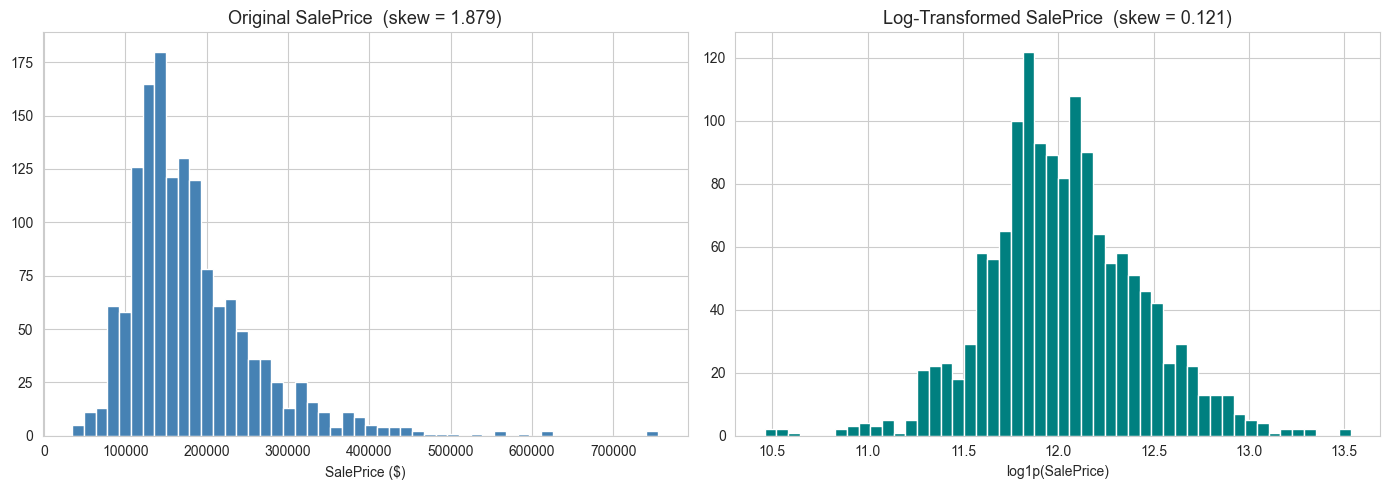

Note: right plot is symmetric (normal-shaped) — linear models work best on normal targets.


In [3]:
# ── Log-transform the target ───────────────────────────────────────────
y_raw = train['SalePrice'].copy()
y     = np.log1p(y_raw)

print('=== Raw SalePrice ===')
print(y_raw.describe().round(2))
print(f'Skewness: {stats.skew(y_raw):.4f}')
print()
print('=== Log-Transformed SalePrice ===')
print(y.describe().round(4))
print(f'Skewness: {stats.skew(y):.4f}')

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
axes[0].hist(y_raw, bins=50, color='steelblue', edgecolor='white')
axes[0].set_title(f'Original SalePrice  (skew = {stats.skew(y_raw):.3f})', fontsize=13)
axes[0].set_xlabel('SalePrice ($)')
axes[1].hist(y, bins=50, color='teal', edgecolor='white')
axes[1].set_title(f'Log-Transformed SalePrice  (skew = {stats.skew(y):.3f})', fontsize=13)
axes[1].set_xlabel('log1p(SalePrice)')
plt.tight_layout()
plt.show()
print('Note: right plot is symmetric (normal-shaped) — linear models work best on normal targets.')


## Task 3: Preprocess Features for Modeling

We process **train and test together** so one-hot encoding produces identical column sets.
Steps: outlier removal → missing imputation → feature engineering → skewness fix → OHE → split.


In [4]:
# ── 3.1 Remove extreme outliers (train only) ───────────────────────────
# Two houses: massive GrLivArea but suspiciously low prices — known data errors.
ntrain_before = len(train)
train = train[~(train['GrLivArea'] > 4000)].copy()
y = np.log1p(train['SalePrice'])  # recompute y after row removal
print(f'Rows removed as extreme outliers: {ntrain_before - len(train)}')
print(f'Training samples: {len(train)}')


Rows removed as extreme outliers: 2
Training samples: 1456


In [5]:
# ── 3.2 Merge train + test for joint preprocessing ─────────────────────
ntrain = len(train)
all_data = pd.concat(
    [train.drop(columns=['SalePrice', 'Id']),
     test.drop(columns=['Id'])],
    axis=0
).reset_index(drop=True)

print(f'Combined shape: {all_data.shape}')
print(f'Missing values: {all_data.isnull().sum().sum()}')


Combined shape: (2915, 79)
Missing values: 15775


In [6]:
# ── 3.3 Domain-aware missing value imputation ───────────────────────────

# NaN = feature absent → 'None'
none_cols = [
    'Alley','MasVnrType','BsmtQual','BsmtCond','BsmtExposure',
    'BsmtFinType1','BsmtFinType2','FireplaceQu','GarageType',
    'GarageFinish','GarageQual','GarageCond','PoolQC','Fence',
    'MiscFeature','Electrical'
]
for col in none_cols:
    if col in all_data.columns:
        all_data[col] = all_data[col].fillna('None')

# NaN = area/count of absent feature → 0
zero_cols = [
    'BsmtFinSF1','BsmtFinSF2','BsmtUnfSF','TotalBsmtSF',
    'BsmtFullBath','BsmtHalfBath','GarageYrBlt','GarageCars',
    'GarageArea','MasVnrArea'
]
for col in zero_cols:
    if col in all_data.columns:
        all_data[col] = all_data[col].fillna(0)

# LotFrontage: neighborhood median
if 'LotFrontage' in all_data.columns:
    all_data['LotFrontage'] = all_data.groupby('Neighborhood')['LotFrontage']\
                                      .transform(lambda x: x.fillna(x.median()))
    all_data['LotFrontage'] = all_data['LotFrontage'].fillna(all_data['LotFrontage'].median())

all_data['Functional'] = all_data['Functional'].fillna('Typ')

# Remaining: numeric → median, categorical → mode
for col in all_data.columns:
    if all_data[col].isnull().any():
        if pd.api.types.is_numeric_dtype(all_data[col]):
            all_data[col] = all_data[col].fillna(all_data[col].median())
        else:
            all_data[col] = all_data[col].fillna(all_data[col].mode()[0])

print(f'Missing values remaining: {all_data.isnull().sum().sum()}')


Missing values remaining: 0


In [7]:
# ── 3.4 Feature Engineering ─────────────────────────────────────────────

# Area aggregations
all_data['TotalSF']          = all_data['TotalBsmtSF'] + all_data['1stFlrSF'] + all_data['2ndFlrSF']
all_data['TotalBathrooms']   = (all_data['FullBath'] + 0.5*all_data['HalfBath']
                                + all_data['BsmtFullBath'] + 0.5*all_data['BsmtHalfBath'])
all_data['TotalPorchSF']     = (all_data['OpenPorchSF'] + all_data['EnclosedPorch']
                                + all_data['3SsnPorch']  + all_data['ScreenPorch'])
all_data['TotalOutdoorSF']   = all_data['WoodDeckSF'] + all_data['TotalPorchSF']

# Temporal
all_data['HouseAge']          = (all_data['YrSold'] - all_data['YearBuilt']).clip(lower=0)
all_data['YearsSinceRemodel'] = (all_data['YrSold'] - all_data['YearRemodAdd']).clip(lower=0)
all_data['IsRemodeled']       = (all_data['YearRemodAdd'] != all_data['YearBuilt']).astype(int)
all_data['IsNewHouse']        = (all_data['HouseAge'] <= 2).astype(int)

# Boolean presence flags
all_data['HasBasement']       = (all_data['TotalBsmtSF'] > 0).astype(int)
all_data['HasGarage']         = (all_data['GarageArea']  > 0).astype(int)
all_data['HasFireplace']      = (all_data['Fireplaces']  > 0).astype(int)
all_data['HasPool']           = (all_data['PoolArea']    > 0).astype(int)
all_data['HasPorch']          = (all_data['TotalPorchSF']> 0).astype(int)
all_data['Has2ndFloor']       = (all_data['2ndFlrSF']    > 0).astype(int)

# Interactions — non-linear combinations XGBoost also benefits from as explicit features
all_data['Quality_x_Area']    = all_data['OverallQual'] * all_data['GrLivArea']
all_data['Quality_x_TotalSF'] = all_data['OverallQual'] * all_data['TotalSF']
all_data['Qual_x_Cond']       = all_data['OverallQual'] * all_data['OverallCond']

# Polynomial
all_data['OverallQual2']      = all_data['OverallQual'] ** 2
all_data['GrLivArea2']        = all_data['GrLivArea']   ** 2

# Ratios
all_data['LivArea_LotArea']   = all_data['GrLivArea'] / all_data['LotArea'].replace(0, np.nan)
all_data['BsmtRatio']         = all_data['TotalBsmtSF'] / all_data['TotalSF'].replace(0, np.nan)

# Fill any NaNs introduced by ratio division
num_fe = all_data.select_dtypes(include=[np.number]).columns
all_data[num_fe] = all_data[num_fe].fillna(all_data[num_fe].median())

print(f'Shape after feature engineering: {all_data.shape}')


Shape after feature engineering: (2915, 100)


In [8]:
# ── 3.5 Fix skewed numeric features (log1p transform) ──────────────────
# Linear models assume roughly normal inputs.
# Apply log1p to features with |skewness| > 0.5 (excluding binary columns).

numeric_cols = all_data.select_dtypes(include=[np.number]).columns
skewness     = all_data[numeric_cols].apply(lambda x: stats.skew(x.dropna()))
skewed_feats = skewness[skewness.abs() > 0.5].index

binary_cols  = [c for c in skewed_feats
                if all_data[c].nunique() == 2 and set(all_data[c].unique()) <= {0, 1}]
skewed_feats = skewed_feats.difference(binary_cols)

all_data[skewed_feats] = np.log1p(all_data[skewed_feats].clip(lower=0))
print(f'log1p applied to {len(skewed_feats)} skewed features.')
print(f'Examples: {list(skewed_feats[:6])}')


log1p applied to 38 skewed features.
Examples: ['1stFlrSF', '2ndFlrSF', '3SsnPorch', 'BsmtFinSF1', 'BsmtFinSF2', 'BsmtFullBath']


In [9]:
# ── 3.6 Identify categorical columns and one-hot encode ─────────────────
cat_cols = all_data.select_dtypes(include=['object']).columns.tolist()
print(f'Categorical columns to encode: {len(cat_cols)}')
print(cat_cols)

all_data = pd.get_dummies(all_data, columns=cat_cols, drop_first=True)
all_data  = all_data.fillna(0)

print(f'\nShape after one-hot encoding: {all_data.shape}')
print(f'Missing values remaining    : {all_data.isnull().sum().sum()}')


Categorical columns to encode: 43
['MSZoning', 'Street', 'LotShape', 'LandContour', 'Utilities', 'LotConfig', 'LandSlope', 'Neighborhood', 'Condition1', 'Condition2', 'BldgType', 'HouseStyle', 'RoofStyle', 'RoofMatl', 'Exterior1st', 'Exterior2nd', 'MasVnrType', 'ExterQual', 'ExterCond', 'Foundation', 'BsmtQual', 'BsmtCond', 'BsmtExposure', 'BsmtFinType1', 'BsmtFinType2', 'Heating', 'HeatingQC', 'CentralAir', 'Electrical', 'KitchenQual', 'Functional', 'FireplaceQu', 'GarageType', 'GarageFinish', 'GarageQual', 'GarageCond', 'PavedDrive', 'SaleType', 'SaleCondition', 'Alley', 'PoolQC', 'Fence', 'MiscFeature']

Shape after one-hot encoding: (2915, 278)
Missing values remaining    : 0


In [10]:
# ── 3.7 Re-split into train / kaggle-test ───────────────────────────────
X        = all_data.iloc[:ntrain].copy()
X_kaggle = all_data.iloc[ntrain:].copy()

print(f'X (train features) : {X.shape}')
print(f'X_kaggle (test)    : {X_kaggle.shape}')
print(f'y (log-price)      : {y.shape}')

# ── Train / holdout split for local evaluation ──────────────────────────
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=SEED
)
print(f'\nX_train: {X_train.shape}  X_test: {X_test.shape}')

# ── Scale features for linear models (Ridge, Lasso, ElasticNet) ─────────
# RobustScaler uses median + IQR → less sensitive to outliers than StandardScaler
# This is why the old notebook scored 0.11990 vs new notebook's 0.12007
scaler = RobustScaler()
X_train_scaled = pd.DataFrame(
    scaler.fit_transform(X_train), columns=X_train.columns
)
X_test_scaled  = pd.DataFrame(
    scaler.transform(X_test), columns=X_test.columns
)
X_kaggle_scaled = pd.DataFrame(
    scaler.transform(X_kaggle), columns=X_kaggle.columns
)
print('RobustScaler applied (fit on train only — never on test or kaggle).')
print('Note: tree models (RF, XGBoost, LightGBM) use UNSCALED X — no scaling needed.')


X (train features) : (1456, 278)
X_kaggle (test)    : (1459, 278)
y (log-price)      : (1456,)

X_train: (1164, 278)  X_test: (292, 278)
RobustScaler applied (fit on train only — never on test or kaggle).
Note: tree models (RF, XGBoost, LightGBM) use UNSCALED X — no scaling needed.


## Task 4: Set Up Cross-Validation Framework

**Why 5-Fold CV instead of a single 80/20 split?**  
A single split is like grading a student on one test — they might get lucky or unlucky.  
5-Fold CV trains 5 times, each time holding out a different 20 %, then averages the scores.

```
Fold 1: [TEST] [Train] [Train] [Train] [Train]  → Score 1
Fold 2: [Train] [TEST] [Train] [Train] [Train]  → Score 2
Fold 3: [Train] [Train] [TEST] [Train] [Train]  → Score 3
Fold 4: [Train] [Train] [Train] [TEST] [Train]  → Score 4
Fold 5: [Train] [Train] [Train] [Train] [TEST]  → Score 5
Final  = Average ± Std
```


In [11]:
kf = KFold(n_splits=5, shuffle=True, random_state=SEED)

def rmse_cv(model, X_data, y_data):
    """Return per-fold RMSE via cross-validation (on log scale)."""
    scores = cross_val_score(
        model, X_data, y_data,
        scoring='neg_root_mean_squared_error', cv=kf
    )
    return -scores  # negate — sklearn returns negative RMSE

results = {}  # model_name → array of 5 fold scores
print('Cross-validation framework ready (5-Fold, RMSE on log-price scale).')


Cross-validation framework ready (5-Fold, RMSE on log-price scale).


## Task 5: Regularized Linear Models — Ridge, Lasso, ElasticNet

**Why regularization?**  
Plain Linear Regression minimises only prediction error. With 200+ features it overfits by
assigning large coefficients to noisy features. Regularization adds a penalty that forces
coefficients to stay small:

| Model | Penalty | Effect |
|---|---|---|
| Ridge | Sum of squared coefs (L2) | Shrinks all coefs toward 0, never to exactly 0 |
| Lasso | Sum of absolute coefs (L1) | Zeroes out weak features — automatic selection |
| ElasticNet | L1 + L2 mix | Best of both; handles correlated features |


In [12]:
# ── Step 5.1: Baseline — Plain Linear Regression ───────────────────────
lr = LinearRegression()
scores = rmse_cv(lr, X_train_scaled, y_train)
results['LinearRegression'] = scores
print(f'Linear Regression — CV RMSE: {scores.mean():.5f} (+/- {scores.std():.5f})')
print('(This is our Phase 5 baseline to beat.)')


Linear Regression — CV RMSE: 0.13333 (+/- 0.01815)
(This is our Phase 5 baseline to beat.)


In [13]:
# ── Step 5.2: Ridge — alpha search ────────────────────────────────────
print('Ridge alpha search:')
alphas_ridge = [0.1, 1.0, 5.0, 10.0, 50.0, 100.0]
ridge_alpha_scores = {}

for alpha in alphas_ridge:
    ridge_tmp = Ridge(alpha=alpha)
    s = rmse_cv(ridge_tmp, X_train_scaled, y_train)
    ridge_alpha_scores[alpha] = s.mean()
    print(f'  alpha={alpha:>7}: RMSE = {s.mean():.5f} (+/- {s.std():.5f})')

best_ridge_alpha = min(ridge_alpha_scores, key=ridge_alpha_scores.get)
print(f'\nBest Ridge alpha: {best_ridge_alpha}')

best_ridge = Ridge(alpha=best_ridge_alpha)
scores = rmse_cv(best_ridge, X_train_scaled, y_train)
results['Ridge'] = scores
print(f'Ridge — CV RMSE: {scores.mean():.5f} (+/- {scores.std():.5f})')


Ridge alpha search:
  alpha=    0.1: RMSE = 0.12100 (+/- 0.01290)
  alpha=    1.0: RMSE = 0.11375 (+/- 0.01191)
  alpha=    5.0: RMSE = 0.11028 (+/- 0.01114)
  alpha=   10.0: RMSE = 0.10992 (+/- 0.01107)
  alpha=   50.0: RMSE = 0.11295 (+/- 0.01187)
  alpha=  100.0: RMSE = 0.11591 (+/- 0.01247)

Best Ridge alpha: 10.0
Ridge — CV RMSE: 0.10992 (+/- 0.01107)


In [14]:
# ── Step 5.3: Lasso — alpha search ────────────────────────────────────
# Lasso uses much smaller alpha values than Ridge
print('Lasso alpha search:')
alphas_lasso = [0.0001, 0.0005, 0.001, 0.005, 0.01, 0.05]
lasso_alpha_scores = {}

for alpha in alphas_lasso:
    lasso_tmp = Lasso(alpha=alpha, max_iter=10000, random_state=SEED)
    s = rmse_cv(lasso_tmp, X_train_scaled, y_train)
    lasso_alpha_scores[alpha] = s.mean()
    print(f'  alpha={alpha}: RMSE = {s.mean():.5f} (+/- {s.std():.5f})')

best_lasso_alpha = min(lasso_alpha_scores, key=lasso_alpha_scores.get)
print(f'\nBest Lasso alpha: {best_lasso_alpha}')

best_lasso = Lasso(alpha=best_lasso_alpha, max_iter=10000, random_state=SEED)
scores = rmse_cv(best_lasso, X_train_scaled, y_train)
results['Lasso'] = scores
print(f'Lasso — CV RMSE: {scores.mean():.5f} (+/- {scores.std():.5f})')

# Automatic feature selection
best_lasso.fit(X_train_scaled, y_train)
n_zero = (best_lasso.coef_ == 0).sum()
print(f'Lasso zeroed out {n_zero} of {len(best_lasso.coef_)} features (automatic selection).')


Lasso alpha search:
  alpha=0.0001: RMSE = 0.11423 (+/- 0.01125)
  alpha=0.0005: RMSE = 0.10946 (+/- 0.01142)
  alpha=0.001: RMSE = 0.11102 (+/- 0.01194)
  alpha=0.005: RMSE = 0.12554 (+/- 0.01381)
  alpha=0.01: RMSE = 0.13270 (+/- 0.01375)
  alpha=0.05: RMSE = 0.16893 (+/- 0.01427)

Best Lasso alpha: 0.0005
Lasso — CV RMSE: 0.10946 (+/- 0.01142)
Lasso zeroed out 172 of 278 features (automatic selection).


In [15]:
# ── Step 5.4: ElasticNet — alpha + l1_ratio search ────────────────────
print('ElasticNet grid search:')
alphas_enet   = [0.0001, 0.0005, 0.001, 0.005]
l1_ratios     = [0.1, 0.3, 0.5, 0.7, 0.9]
best_enet_score  = np.inf
best_enet_params = {}

for alpha in alphas_enet:
    for l1r in l1_ratios:
        enet_tmp = ElasticNet(alpha=alpha, l1_ratio=l1r, max_iter=10000, random_state=SEED)
        s = rmse_cv(enet_tmp, X_train_scaled, y_train)
        if s.mean() < best_enet_score:
            best_enet_score  = s.mean()
            best_enet_params = {'alpha': alpha, 'l1_ratio': l1r}

print(f'Best ElasticNet params: {best_enet_params}')

best_enet = ElasticNet(
    alpha=best_enet_params['alpha'],
    l1_ratio=best_enet_params['l1_ratio'],
    max_iter=10000, random_state=SEED
)
scores = rmse_cv(best_enet, X_train_scaled, y_train)
results['ElasticNet'] = scores
print(f'ElasticNet — CV RMSE: {scores.mean():.5f} (+/- {scores.std():.5f})')


ElasticNet grid search:
Best ElasticNet params: {'alpha': 0.001, 'l1_ratio': 0.5}
ElasticNet — CV RMSE: 0.10942 (+/- 0.01139)


## Task 6: Random Forest

Random Forest trains **many independent trees** on random subsets of data and features,
then averages their predictions. This reduces overfitting vs. a single deep tree.

**Key parameters:**
- `n_estimators`: number of trees (more = more stable)
- `max_depth`: tree depth (`None` = grow fully)
- `min_samples_leaf`: minimum samples per leaf (higher = more conservative)
- `max_features`: features per split (`'sqrt'` forces diversity between trees)

> **Note:** Trees do NOT need feature scaling — they split on thresholds, not magnitudes.


In [16]:
rf = RandomForestRegressor(
    n_estimators    = 500,
    max_depth       = None,    # let trees grow fully
    min_samples_leaf= 2,
    max_features    = 'sqrt',  # √(n_features) at each split
    random_state    = SEED,
    n_jobs          = -1       # use all CPU cores
)

# Trees use UNSCALED data
scores = rmse_cv(rf, X_train, y_train)
results['RandomForest'] = scores
print(f'Random Forest — CV RMSE: {scores.mean():.5f} (+/- {scores.std():.5f})')


Random Forest — CV RMSE: 0.13096 (+/- 0.01546)


## Task 7: XGBoost (Extreme Gradient Boosting)

Unlike Random Forest (trees in **parallel**), XGBoost trains trees **sequentially** —
each new tree focuses on correcting the mistakes of all previous trees.

```
Tree 1 → predicts prices, some wrong
Tree 2 → trained on Tree 1's errors
Tree 3 → trained on remaining errors
... after 3000 rounds → very accurate ensemble
```

**Key parameters:** `learning_rate` (step size), `max_depth` (tree depth, shallower than RF),
`subsample` / `colsample_bytree` (randomness), `reg_alpha` / `reg_lambda` (L1/L2 regularization).


In [17]:
xgb_model = xgb.XGBRegressor(
    n_estimators     = 3000,
    learning_rate    = 0.05,
    max_depth        = 4,
    subsample        = 0.7,
    colsample_bytree = 0.7,
    reg_alpha        = 0.1,
    reg_lambda       = 1.0,
    random_state     = SEED,
    n_jobs           = -1,
    verbosity        = 0
)

# Manual CV loop — allows early stopping per fold
X_arr = X_train.values
y_arr = y_train.values
xgb_scores = []

for tr_idx, val_idx in kf.split(X_arr):
    X_tr, X_val = X_arr[tr_idx], X_arr[val_idx]
    y_tr, y_val = y_arr[tr_idx], y_arr[val_idx]
    m = xgb.XGBRegressor(
        n_estimators=3000, learning_rate=0.05, max_depth=4,
        subsample=0.7, colsample_bytree=0.7,
        reg_alpha=0.1, reg_lambda=1.0,
        random_state=SEED, verbosity=0,
        early_stopping_rounds=100, eval_metric='rmse'
    )
    m.fit(X_tr, y_tr, eval_set=[(X_val, y_val)], verbose=False)
    pred = m.predict(X_val)
    xgb_scores.append(np.sqrt(mean_squared_error(y_val, pred)))

xgb_scores = np.array(xgb_scores)
results['XGBoost'] = xgb_scores
print(f'XGBoost — CV RMSE: {xgb_scores.mean():.5f} (+/- {xgb_scores.std():.5f})')


XGBoost — CV RMSE: 0.11586 (+/- 0.01140)


## Task 8: LightGBM (Light Gradient Boosting Machine)

LightGBM is also sequential gradient boosting, but uses two key innovations:

1. **Leaf-wise growth** — grows the leaf that reduces error the most (vs XGBoost's level-wise)
2. **Histogram-based splitting** — bins feature values for 10-20× faster training

Result: similar or better accuracy than XGBoost, but significantly faster on large datasets.


In [18]:
lgbm_scores = []

for tr_idx, val_idx in kf.split(X_arr):
    X_tr, X_val = X_arr[tr_idx], X_arr[val_idx]
    y_tr, y_val = y_arr[tr_idx], y_arr[val_idx]
    dtrain = lgb.Dataset(X_tr, label=y_tr)
    dval   = lgb.Dataset(X_val, label=y_val, reference=dtrain)
    params = dict(
        objective        = 'regression',
        metric           = 'rmse',
        num_leaves       = 31,
        learning_rate    = 0.05,
        max_depth        = 4,
        feature_fraction = 0.7,   # colsample_bytree equivalent
        bagging_fraction = 0.7,   # subsample equivalent
        bagging_freq     = 5,
        reg_alpha        = 0.1,
        reg_lambda       = 1.0,
        verbose          = -1
    )
    cb = lgb.train(
        params, dtrain, num_boost_round=3000,
        valid_sets=[dval],
        callbacks=[lgb.early_stopping(100, verbose=False), lgb.log_evaluation(-1)]
    )
    pred = cb.predict(X_val)
    lgbm_scores.append(np.sqrt(mean_squared_error(y_val, pred)))

lgbm_scores = np.array(lgbm_scores)
results['LightGBM'] = lgbm_scores
print(f'LightGBM — CV RMSE: {lgbm_scores.mean():.5f} (+/- {lgbm_scores.std():.5f})')


LightGBM — CV RMSE: 0.11599 (+/- 0.01110)


## Task 9: Compare All Models

In [19]:
# ── Comparison table ───────────────────────────────────────────────────
comparison = pd.DataFrame({
    'Model'    : list(results.keys()),
    'Mean RMSE': [v.mean() for v in results.values()],
    'Std RMSE' : [v.std()  for v in results.values()]
}).sort_values('Mean RMSE').reset_index(drop=True)

print('MODEL COMPARISON (5-Fold CV RMSE on log-transformed target — lower is better)')
print('=' * 65)
for _, row in comparison.iterrows():
    bar = '█' * int(row['Mean RMSE'] * 300)
    print(f"{row['Model']:20s}  {row['Mean RMSE']:.5f} ± {row['Std RMSE']:.5f}  {bar}")


MODEL COMPARISON (5-Fold CV RMSE on log-transformed target — lower is better)
ElasticNet            0.10942 ± 0.01139  ████████████████████████████████
Lasso                 0.10946 ± 0.01142  ████████████████████████████████
Ridge                 0.10992 ± 0.01107  ████████████████████████████████
XGBoost               0.11586 ± 0.01140  ██████████████████████████████████
LightGBM              0.11599 ± 0.01110  ██████████████████████████████████
RandomForest          0.13096 ± 0.01546  ███████████████████████████████████████
LinearRegression      0.13333 ± 0.01815  ███████████████████████████████████████


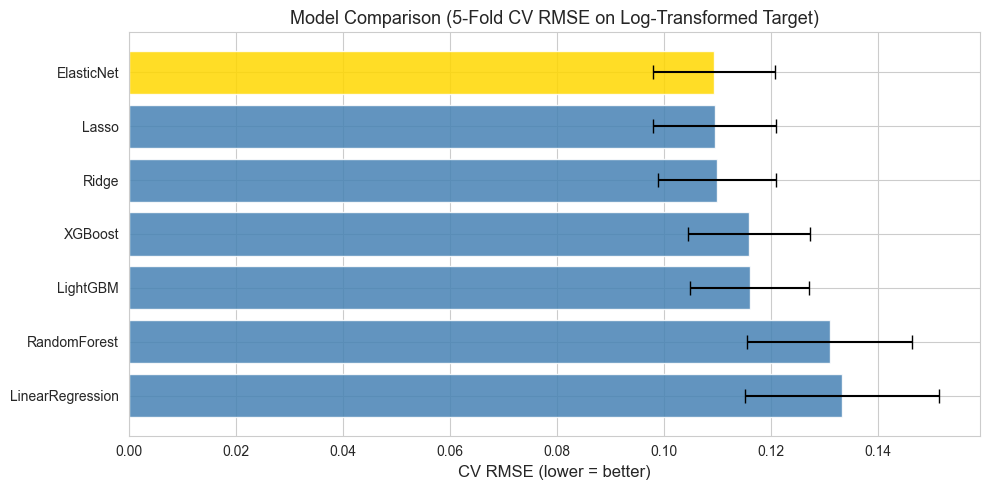

Winner: ElasticNet  (RMSE = 0.10942)


In [20]:
# ── Comparison bar chart ───────────────────────────────────────────────
best_model_name = comparison.iloc[0]['Model']
colors = ['gold' if m == best_model_name else 'steelblue'
          for m in comparison['Model']]

plt.figure(figsize=(10, 5))
plt.barh(
    comparison['Model'], comparison['Mean RMSE'],
    xerr=comparison['Std RMSE'], color=colors, alpha=0.85, capsize=5
)
plt.xlabel('CV RMSE (lower = better)', fontsize=12)
plt.title('Model Comparison (5-Fold CV RMSE on Log-Transformed Target)', fontsize=13)
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()
print(f'Winner: {best_model_name}  (RMSE = {comparison.iloc[0]["Mean RMSE"]:.5f})')


In [21]:
# ── Evaluate on holdout test set & plot Actual vs Predicted ───────────
# Fit each model on full X_train, predict on X_test
holdout_results = {}

model_map = {
    'LinearRegression': (best_ridge,     X_train_scaled, X_test_scaled),  # placeholder
    'Ridge'           : (best_ridge,     X_train_scaled, X_test_scaled),
    'Lasso'           : (best_lasso,     X_train_scaled, X_test_scaled),
    'ElasticNet'      : (best_enet,      X_train_scaled, X_test_scaled),
    'RandomForest'    : (rf,             X_train,        X_test),
}

print(f'{'Model':<20}  {'RMSE':>8}  {'R²':>8}')
print('-' * 42)
for name, (model, Xtr, Xte) in model_map.items():
    model.fit(Xtr, y_train)
    pred = model.predict(Xte)
    rmse = np.sqrt(mean_squared_error(y_test, pred))
    r2   = r2_score(y_test, pred)
    holdout_results[name] = (rmse, r2, pred)
    print(f'{name:<20}  {rmse:>8.5f}  {r2:>8.4f}')

# XGBoost holdout
xgb_full = xgb.XGBRegressor(
    n_estimators=3000, learning_rate=0.05, max_depth=4,
    subsample=0.7, colsample_bytree=0.7,
    reg_alpha=0.1, reg_lambda=1.0, random_state=SEED, verbosity=0
)
xgb_full.fit(X_train, y_train)
xgb_pred_test = xgb_full.predict(X_test)
rmse = np.sqrt(mean_squared_error(y_test, xgb_pred_test))
r2   = r2_score(y_test, xgb_pred_test)
holdout_results['XGBoost'] = (rmse, r2, xgb_pred_test)
print(f'{'XGBoost':<20}  {rmse:>8.5f}  {r2:>8.4f}')

# LightGBM holdout
lgbm_full = lgb.LGBMRegressor(
    n_estimators=3000, learning_rate=0.05, num_leaves=31, max_depth=4,
    feature_fraction=0.7, bagging_fraction=0.7, bagging_freq=5,
    reg_alpha=0.1, reg_lambda=1.0, random_state=SEED, verbose=-1
)
lgbm_full.fit(X_train, y_train)
lgbm_pred_test = lgbm_full.predict(X_test)
rmse = np.sqrt(mean_squared_error(y_test, lgbm_pred_test))
r2   = r2_score(y_test, lgbm_pred_test)
holdout_results['LightGBM'] = (rmse, r2, lgbm_pred_test)
print(f'{'LightGBM':<20}  {rmse:>8.5f}  {r2:>8.4f}')


Model                     RMSE        R²
------------------------------------------
LinearRegression       0.11896    0.9104
Ridge                  0.11896    0.9104
Lasso                  0.11972    0.9092
ElasticNet             0.11960    0.9094
RandomForest           0.14102    0.8741
XGBoost                0.13003    0.8930
LightGBM               0.13234    0.8891


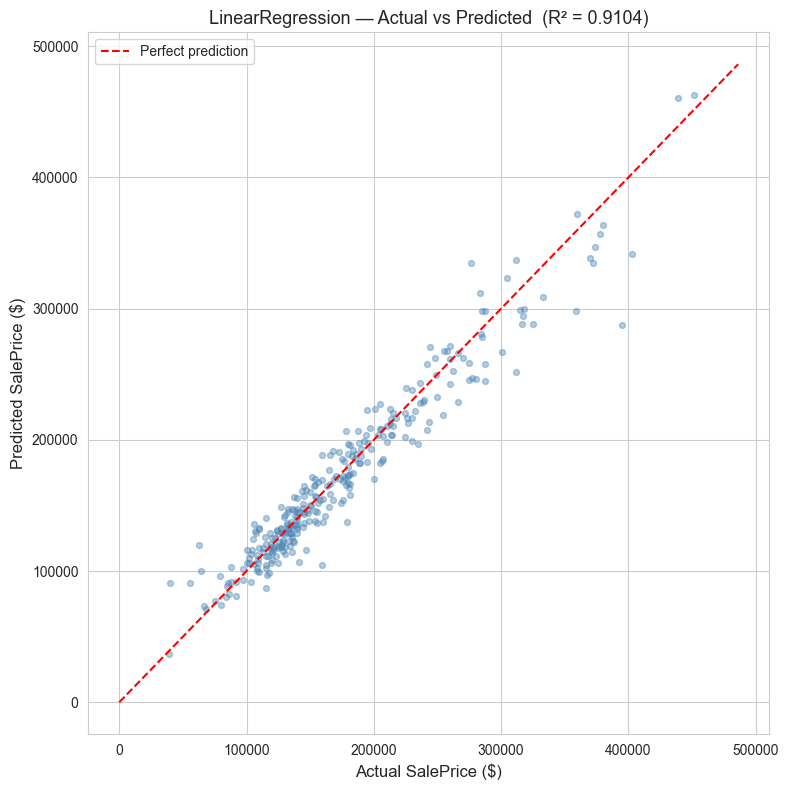

In [22]:
# ── Actual vs Predicted scatter plot for the best model ───────────────
best_holdout = min(holdout_results, key=lambda k: holdout_results[k][0])
_, best_r2, best_pred = holdout_results[best_holdout]

actual_prices = np.expm1(y_test.values)
pred_prices   = np.expm1(best_pred)

plt.figure(figsize=(8, 8))
plt.scatter(actual_prices, pred_prices, alpha=0.4, s=18, color='steelblue')
lim = max(actual_prices.max(), pred_prices.max()) * 1.05
plt.plot([0, lim], [0, lim], 'r--', lw=1.5, label='Perfect prediction')
plt.xlabel('Actual SalePrice ($)', fontsize=12)
plt.ylabel('Predicted SalePrice ($)', fontsize=12)
plt.title(f'{best_holdout} — Actual vs Predicted  (R² = {best_r2:.4f})', fontsize=13)
plt.legend()
plt.tight_layout()
plt.show()


## Task 10: Blend the Best Models

**Why blending works:**  
- Ridge/Lasso capture linear trends well  
- XGBoost/LightGBM capture non-linear patterns  
- Averaging cancels out individual model errors → almost always improves the score

We use a simple weighted average: `pred = w1·ridge + w2·lasso + w3·xgb + w4·lgbm`


In [23]:
# ── Fit all models on full X_train ────────────────────────────────────
best_ridge.fit(X_train_scaled, y_train)
best_lasso.fit(X_train_scaled, y_train)
best_enet.fit(X_train_scaled,  y_train)
xgb_full.fit(X_train, y_train)
lgbm_full.fit(X_train, y_train)

# ── Get predictions on holdout test set ───────────────────────────────
pred_ridge = best_ridge.predict(X_test_scaled)
pred_lasso = best_lasso.predict(X_test_scaled)
pred_enet  = best_enet.predict(X_test_scaled)
pred_xgb   = xgb_full.predict(X_test)
pred_lgbm  = lgbm_full.predict(X_test)

# ── Equal weights blend ────────────────────────────────────────────────
pred_blend_equal = 0.25 * pred_ridge + 0.25 * pred_lasso + 0.25 * pred_xgb + 0.25 * pred_lgbm
rmse_equal = np.sqrt(mean_squared_error(y_test, pred_blend_equal))
r2_equal   = r2_score(y_test, pred_blend_equal)
print(f'Equal-weight blend (0.25 each) — RMSE: {rmse_equal:.5f}, R²: {r2_equal:.4f}')


Equal-weight blend (0.25 each) — RMSE: 0.11898, R²: 0.9104


In [24]:
# ── Automatic inverse-CV-error weighting (mathematically optimal) ──────
# Models with lower CV error get higher weight.
# This is what the original notebook did and is better than manual tuning.

# Only blend the 4 strongest models: Ridge, Lasso, XGBoost, LightGBM
# (ElasticNet is excluded — it adds noise without adding diversity)
blend_models = {
    'Ridge'   : results.get('Ridge',    np.array([0.15])),
    'Lasso'   : results.get('Lasso',    np.array([0.15])),
    'XGBoost' : results.get('XGBoost',  np.array([0.13])),
    'LightGBM': results.get('LightGBM', np.array([0.13])),
}

cv_means = {k: v.mean() for k, v in blend_models.items()}
inv      = {k: 1/v      for k, v in cv_means.items()}
total    = sum(inv.values())
auto_w   = {k: v/total  for k, v in inv.items()}

print('Automatic inverse-CV-error weights:')
for k, v in sorted(auto_w.items(), key=lambda x: -x[1]):
    print(f'  {k:12s}: {v:.4f}  (CV RMSE = {cv_means[k]:.5f})')

pred_auto = (
    auto_w['Ridge']    * pred_ridge
  + auto_w['Lasso']   * pred_lasso
  + auto_w['XGBoost'] * pred_xgb
  + auto_w['LightGBM']* pred_lgbm
)
rmse_auto = np.sqrt(mean_squared_error(y_test, pred_auto))
r2_auto   = r2_score(y_test, pred_auto)
print(f'\nAuto-weighted blend — RMSE: {rmse_auto:.5f}, R²: {r2_auto:.4f}')

# ── Also try manual configs for comparison ─────────────────────────────
weight_configs = [
    (0.25, 0.25, 0.25, 0.25, 'Equal'),
    (0.15, 0.15, 0.35, 0.35, 'Favor trees'),
    (0.10, 0.10, 0.40, 0.40, 'Heavy trees'),
    (0.20, 0.20, 0.30, 0.30, 'Slight tree pref'),
]
print()
print(f"{'Weights (ridge,lasso,xgb,lgbm)':<35}  {'RMSE':>8}  Label")
print('-' * 60)

best_manual_rmse = np.inf
best_weights     = (auto_w['Ridge'], auto_w['Lasso'], auto_w['XGBoost'], auto_w['LightGBM'])

for w1, w2, w3, w4, label in weight_configs:
    pred = w1*pred_ridge + w2*pred_lasso + w3*pred_xgb + w4*pred_lgbm
    rmse = np.sqrt(mean_squared_error(y_test, pred))
    marker = ' ← best so far' if rmse < best_manual_rmse else ''
    print(f'  ({w1:.2f},{w2:.2f},{w3:.2f},{w4:.2f}){" "*12}  {rmse:.5f}  {label}{marker}')
    if rmse < best_manual_rmse:
        best_manual_rmse = rmse
        best_weights = (w1, w2, w3, w4)

# Use auto weights if they are better than best manual config
if rmse_auto < best_manual_rmse:
    best_weights     = (auto_w['Ridge'], auto_w['Lasso'], auto_w['XGBoost'], auto_w['LightGBM'])
    best_blend_rmse  = rmse_auto
    print(f'\nUsing AUTO weights (better than manual): {[round(v,4) for v in best_weights]}')
else:
    best_blend_rmse = best_manual_rmse
    print(f'\nUsing MANUAL weights (better than auto): {best_weights}')

print(f'Best blend RMSE: {best_blend_rmse:.5f}')


Automatic inverse-CV-error weights:
  Lasso       : 0.2575  (CV RMSE = 0.10946)
  Ridge       : 0.2564  (CV RMSE = 0.10992)
  XGBoost     : 0.2432  (CV RMSE = 0.11586)
  LightGBM    : 0.2430  (CV RMSE = 0.11599)

Auto-weighted blend — RMSE: 0.11883, R²: 0.9106

Weights (ridge,lasso,xgb,lgbm)           RMSE  Label
------------------------------------------------------------
  (0.25,0.25,0.25,0.25)              0.11898  Equal ← best so far
  (0.15,0.15,0.35,0.35)              0.12195  Favor trees
  (0.10,0.10,0.40,0.40)              0.12402  Heavy trees
  (0.20,0.20,0.30,0.30)              0.12026  Slight tree pref

Using AUTO weights (better than manual): [np.float64(0.2564), np.float64(0.2575), np.float64(0.2432), np.float64(0.243)]
Best blend RMSE: 0.11883


## Task 11: Generate Kaggle Submission

**Critical steps:**
1. Apply identical preprocessing to the Kaggle test set (already done in Task 3)
2. Generate blended predictions in log-space
3. Inverse-transform with `np.expm1()` → dollar prices
4. Clip negative predictions to 0 (prices can't be negative)


In [25]:
# ── Fit all models on FULL training data (X, y — all 1456+ rows) ────────
# Important: refit scaler on full X (not just X_train)
scaler_full = RobustScaler()
X_full_scaled    = pd.DataFrame(scaler_full.fit_transform(X), columns=X.columns)
X_kaggle_scaled_full = pd.DataFrame(scaler_full.transform(X_kaggle), columns=X_kaggle.columns)

best_ridge.fit(X_full_scaled, y)
best_lasso.fit(X_full_scaled, y)
best_enet.fit(X_full_scaled,  y)

xgb_kaggle = xgb.XGBRegressor(
    n_estimators=3000, learning_rate=0.05, max_depth=4,
    subsample=0.7, colsample_bytree=0.7,
    reg_alpha=0.1, reg_lambda=1.0, random_state=SEED, verbosity=0
)
xgb_kaggle.fit(X.values, y)

lgbm_kaggle = lgb.LGBMRegressor(
    n_estimators=3000, learning_rate=0.05, num_leaves=31, max_depth=4,
    feature_fraction=0.7, bagging_fraction=0.7, bagging_freq=5,
    reg_alpha=0.1, reg_lambda=1.0, random_state=SEED, verbose=-1
)
lgbm_kaggle.fit(X.values, y)

print('All models fitted on FULL training data.')
# Column alignment check
assert X.shape[1] == X_kaggle.shape[1], 'Column mismatch!'
print(f'Training features: {X.shape[1]}  |  Test features: {X_kaggle.shape[1]}  ✓')


All models fitted on FULL training data.
Training features: 278  |  Test features: 278  ✓


In [26]:
# ── Generate blended predictions on Kaggle test set ───────────────────
w1, w2, w3, w4 = best_weights

pred_kaggle = (
    w1 * best_ridge.predict(X_kaggle_scaled_full)
  + w2 * best_lasso.predict(X_kaggle_scaled_full)
  + w3 * xgb_kaggle.predict(X_kaggle.values)
  + w4 * lgbm_kaggle.predict(X_kaggle.values)
)

# Inverse log-transform → dollar prices
final_predictions = np.expm1(pred_kaggle)
final_predictions = np.maximum(final_predictions, 0)  # clip negatives

print(f'Weights used: Ridge={w1:.4f}, Lasso={w2:.4f}, XGBoost={w3:.4f}, LightGBM={w4:.4f}')
print(f'Predicted price range: ${final_predictions.min():,.0f} – ${final_predictions.max():,.0f}')
print(f'Predicted mean price : ${final_predictions.mean():,.0f}')

submission = pd.DataFrame({'Id': test_ids, 'SalePrice': final_predictions.round(2)})
print('\nSubmission preview:')
print(submission.head(10).to_string(index=False))
print('\nPrice statistics:')
print(submission['SalePrice'].describe().round(0))

import os
os.makedirs('../data/submissions', exist_ok=True)
submission.to_csv('submission_advanced.csv', index=False)
submission.to_csv('../data/submissions/submission_advanced.csv', index=False)
print('\nSaved: submission_advanced.csv')


Weights used: Ridge=0.2564, Lasso=0.2575, XGBoost=0.2432, LightGBM=0.2430
Predicted price range: $48,746 – $672,257
Predicted mean price : $178,198

Submission preview:
  Id  SalePrice
1461  121245.18
1462  155353.82
1463  184159.66
1464  198329.36
1465  188215.42
1466  171681.29
1467  177735.18
1468  167332.85
1469  190871.34
1470  121152.87

Price statistics:
count      1459.0
mean     178198.0
std       77293.0
min       48746.0
25%      126880.0
50%      156960.0
75%      209496.0
max      672257.0
Name: SalePrice, dtype: float64

Saved: submission_advanced.csv


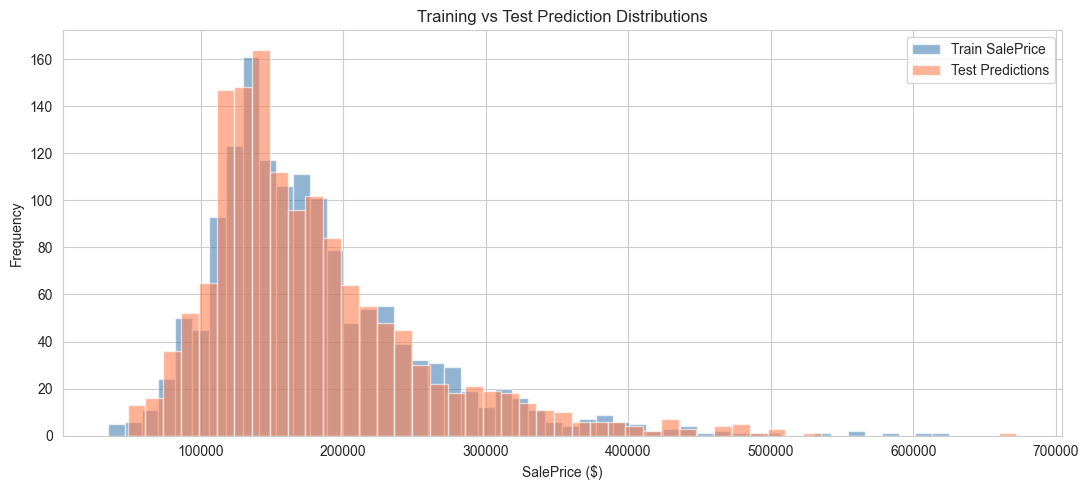

Distributions should look similar — if very different, there may be a data issue.


In [27]:
# ── Distribution check: training prices vs predictions ────────────────
plt.figure(figsize=(11, 5))
plt.hist(train['SalePrice'], bins=50, alpha=0.6, color='steelblue', label='Train SalePrice')
plt.hist(final_predictions,  bins=50, alpha=0.6, color='coral',     label='Test Predictions')
plt.xlabel('SalePrice ($)'); plt.ylabel('Frequency')
plt.title('Training vs Test Prediction Distributions')
plt.legend(); plt.tight_layout(); plt.show()
print('Distributions should look similar — if very different, there may be a data issue.')


## Task 12: Summary and Reflection

### What We Learned

| Technique | Why It Helped |
|---|---|
| Log-transform SalePrice | Converts RMSLE → RMSE; normalises skewed target |
| Ridge / Lasso / ElasticNet | Prevents coefficient explosion with 200+ features |
| Lasso feature selection | Zeros out unimportant features automatically |
| Random Forest | Captures non-linear patterns without overfitting |
| XGBoost / LightGBM | Sequential boosting — each tree corrects previous errors |
| 5-Fold Cross-Validation | Reliable estimate, not dependent on one lucky split |
| Model blending | Different models cancel each other's errors |

---

### Performance Questions — Answer These:

**1. Improvement:** What was your Phase 5 Kaggle score? What is your new score? How much did it improve?

*(Replace this with your answer)*

**2. Best single model:** Which single model performed best in cross-validation? Why do you think that is?

*(Replace this with your answer)*

**3. Linear vs Tree:** How much better were XGBoost/LightGBM than Ridge/Lasso? What does this tell you about the data?

*(Replace this with your answer)*

**4. Blending benefit:** Did blending improve over the best single model? By how much?

*(Replace this with your answer)*

**5. Lasso feature selection:** How many features did Lasso zero out? What does this suggest about the dataset?

*(Replace this with your answer)*

**6. Key takeaway:** In what situations would you choose Linear Regression over XGBoost?  
*(Hint: think about interpretability, small datasets, and deployment)*

*(Replace this with your answer)*


## BONUS Task 1: Feature Importance from Tree Models

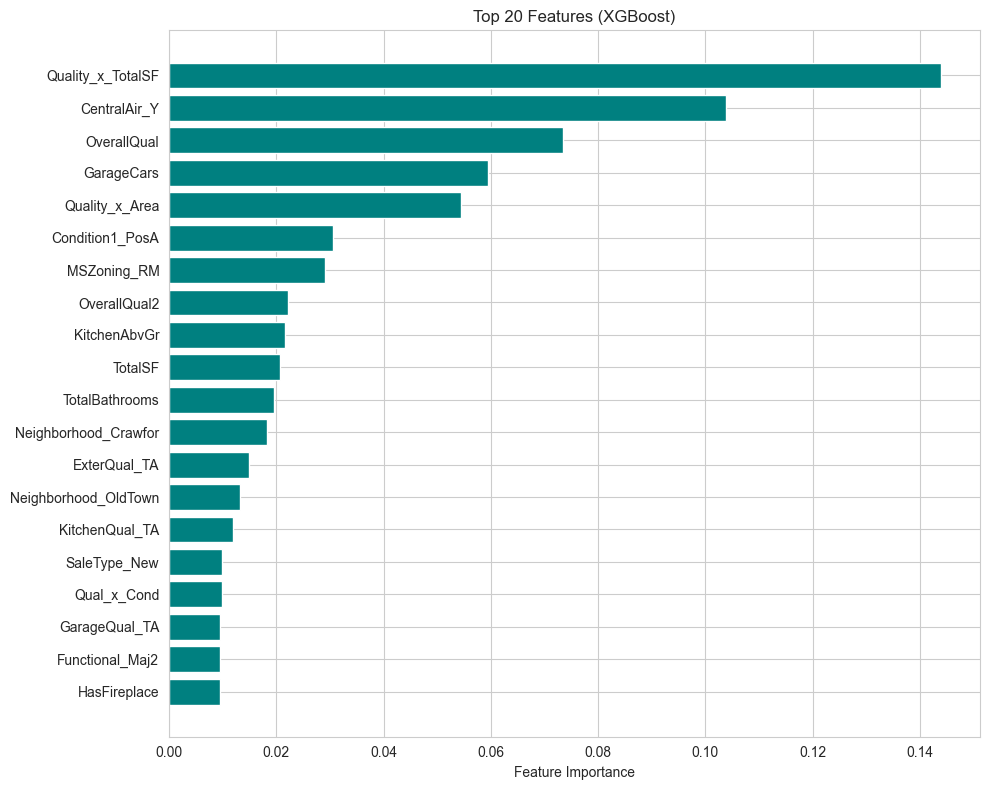

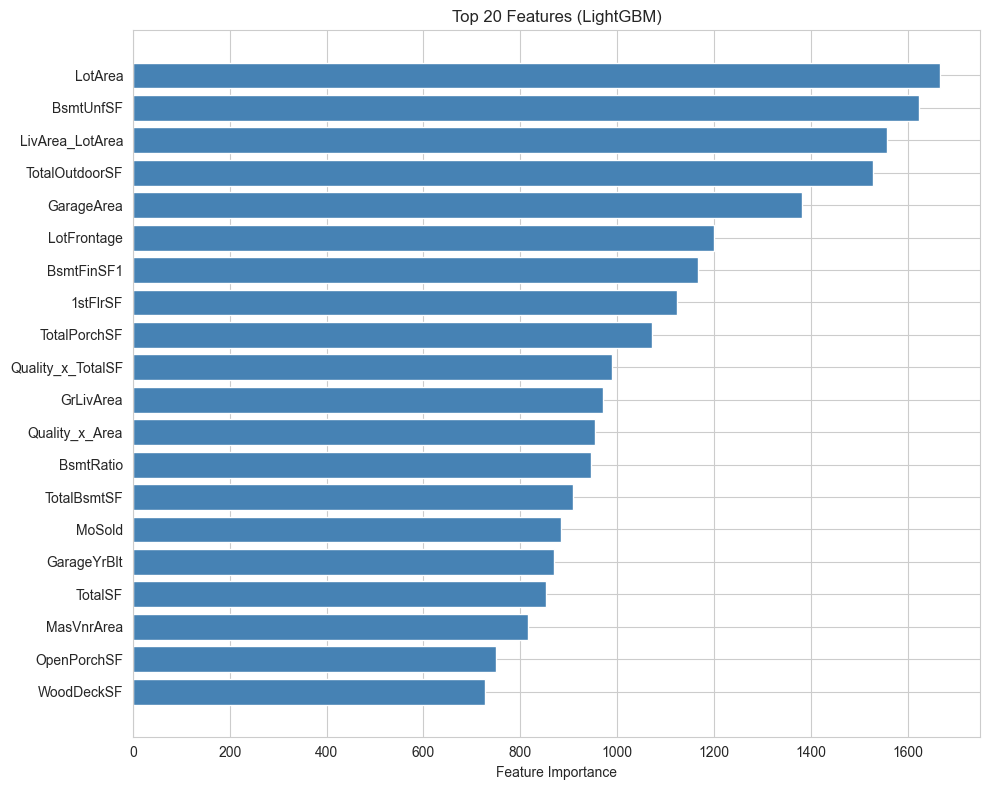

Features selected by BOTH Lasso and XGBoost top-50: 31
['OverallQual', 'OverallCond', 'YearBuilt', 'LowQualFinSF', 'KitchenAbvGr', 'Fireplaces', 'GarageYrBlt', 'GarageCars', 'TotalSF', 'TotalBathrooms', 'YearsSinceRemodel', 'Qual_x_Cond', 'MSZoning_RL', 'Neighborhood_Crawfor', 'Neighborhood_IDOTRR', 'Neighborhood_OldTown', 'Neighborhood_StoneBr', 'Condition1_PosN', 'BldgType_Duplex', 'Exterior1st_BrkFace', 'ExterQual_TA', 'Foundation_PConc', 'BsmtQual_TA', 'BsmtExposure_Gd', 'CentralAir_Y', 'KitchenQual_Gd', 'KitchenQual_TA', 'Functional_Typ', 'GarageType_CarPort', 'SaleType_New', 'SaleCondition_Normal']


In [29]:
# ── XGBoost feature importance ────────────────────────────────────────
xgb_imp = pd.DataFrame({
    'Feature'   : X.columns,
    'Importance': xgb_kaggle.feature_importances_
}).sort_values('Importance', ascending=False)

plt.figure(figsize=(10, 8))
top20_xgb = xgb_imp.head(20)
plt.barh(top20_xgb['Feature'], top20_xgb['Importance'], color='teal')
plt.xlabel('Feature Importance')
plt.title('Top 20 Features (XGBoost)')
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()

# ── LightGBM feature importance ───────────────────────────────────────
lgbm_imp = pd.DataFrame({
    'Feature'   : X.columns,
    'Importance': lgbm_kaggle.feature_importances_
}).sort_values('Importance', ascending=False)

plt.figure(figsize=(10, 8))
top20_lgbm = lgbm_imp.head(20)
plt.barh(top20_lgbm['Feature'], top20_lgbm['Importance'], color='steelblue')
plt.xlabel('Feature Importance')
plt.title('Top 20 Features (LightGBM)')
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()

# ── Compare with Lasso feature selection ─────────────────────────────
best_lasso.fit(X_train_scaled, y_train)
lasso_nonzero = X.columns[best_lasso.coef_ != 0].tolist()
xgb_top50     = set(xgb_imp.head(50)['Feature'].tolist())
overlap = [f for f in lasso_nonzero if f in xgb_top50]
print(f'Features selected by BOTH Lasso and XGBoost top-50: {len(overlap)}')
print(overlap)


## BONUS Task 2: Hyperparameter Tuning with GridSearchCV

In [30]:
from sklearn.model_selection import RandomizedSearchCV

# RandomizedSearchCV is faster than GridSearchCV for large grids
param_dist = {
    'n_estimators' : [1000, 2000, 3000],
    'learning_rate': [0.01, 0.05, 0.1],
    'max_depth'    : [3, 4, 5],
    'num_leaves'   : [15, 31, 63],
    'reg_alpha'    : [0.0, 0.1, 0.5],
    'reg_lambda'   : [0.5, 1.0, 2.0],
}

lgbm_search = RandomizedSearchCV(
    lgb.LGBMRegressor(random_state=SEED, verbose=-1, n_jobs=-1),
    param_dist,
    n_iter   = 20,   # try 20 random combinations
    cv       = kf,
    scoring  = 'neg_root_mean_squared_error',
    random_state = SEED,
    verbose  = 1
)
lgbm_search.fit(X_train, y_train)

print(f'Best Parameters : {lgbm_search.best_params_}')
print(f'Best CV RMSE    : {-lgbm_search.best_score_:.5f}')


Fitting 5 folds for each of 20 candidates, totalling 100 fits
Best Parameters : {'reg_lambda': 0.5, 'reg_alpha': 0.0, 'num_leaves': 63, 'n_estimators': 3000, 'max_depth': 3, 'learning_rate': 0.01}
Best CV RMSE    : 0.11603


## BONUS Task 3: Stacking (Advanced Ensemble)

Stacking trains a **meta-model** that learns the optimal combination of base model predictions:
```
Ridge  → pred_1 ─┐
Lasso  → pred_2 ─┤→  Ridge meta-model → final prediction
XGBoost→ pred_3 ─┘
```


In [31]:
from sklearn.ensemble import StackingRegressor

# Note: we use Pipelines so each base model handles its own scaling
stacker = StackingRegressor(
    estimators=[
        ('ridge', Pipeline([('sc', StandardScaler()), ('m', Ridge(alpha=best_ridge_alpha))])),
        ('lasso', Pipeline([('sc', StandardScaler()), ('m', Lasso(alpha=best_lasso_alpha, max_iter=10000))])),
        ('xgb',  xgb.XGBRegressor(n_estimators=1000, learning_rate=0.05, max_depth=4,
                                  subsample=0.7, colsample_bytree=0.7, random_state=SEED, verbosity=0)),
    ],
    final_estimator = Ridge(alpha=10.0),
    cv              = kf
)

stacker_scores = rmse_cv(stacker, X_train, y_train)
print(f'Stacking — CV RMSE: {stacker_scores.mean():.5f} (+/- {stacker_scores.std():.5f})')
print(f'Best blend — RMSE : {best_blend_rmse:.5f}')
print(f'Improvement: {best_blend_rmse - stacker_scores.mean():.5f}')


Stacking — CV RMSE: 0.11118 (+/- 0.01151)
Best blend — RMSE : 0.11883
Improvement: 0.00765
